<a href="https://colab.research.google.com/github/dsl-unibe-ch/machine-learning/blob/master/4_ML_UL_PCA_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine learning - Unsupervised Learning

**Lecturer:** Ana Stojiljkovic, DVM PhD  
Data Science Lab, University of Bern | 2026

---

*Based on the original teaching materials developed by Mykhailo Vladymyrov and Aris Marcolongo, Data Science Lab, University of Bern (2023).*

*Original material: [DSF5 GitHub repository](https://github.com/neworldemancer/DSF5).*

*This work is licensed under [CC0 1.0 Universal](https://creativecommons.org/publicdomain/zero/1.0/).*

## 1. Learning outcomes

By the end of this session, you will be able to:

- Explain the difference between supervised and unsupervised learning.
- Explain why high-dimensional data can be difficult to visualize.
- Apply Principal Component Analysis (PCA) to reduce the dimensionality of a dataset.
- Interpret PCA visualizations and explained variance.
- Identify limitations of dimensionality reduction and avoid overinterpreting visualizations.

## 2. Supervised vs Unsupervised

**Supervised learning** techniques, such as regression and classification, are used to predict know outcomes, such as a numerical value or a category, from a set of input features.

But what if you have data **without a predefined outcome to predict?**

*Imagine that we have information about hundreds of customers, but we do not know whether they belong to distinct groups. Can we identify meaningful groups based on similarities in their behaviour?*

**Unsupervised learning** methods, instead of learning from known target values, use algorithms to identify patterns and structure in the data. These methods allow us, for example, to represent complex data using fewer dimensions or group similar observations through clustering.

![Machine learning algorithm selection guide](figures/cheatsheet.png)

*Source: [scikit-learn algorithm selection guide](https://scikit-learn.org/stable/machine_learning_map.html).*

## 3. Dimensionality Reduction
In unsupervised learning, we do not aim to predict a predefined target $Y$ from our features $X$. Instead, we investigate patterns and structure in the data cloud $X$.

Many datasets contain a large number of features $D$, represented by a data matrix of shape $N \times D$, where $N$ is the number of observations.

**Dimensionality reduction** aims to represent the data using fewer features $M$, producing a new data matrix of shape $N \times M$, where $M \ll D$, while preserving as much relevant information as possible.

The resulting lower-dimensional representation is called an **embedding**. Each observation is represented by a new set of M coordinates, which we can use, for example, to visualize the data in two dimensions.


### Methods

- **PCA (Principal Component Analysis):** A linear method that identifies new axes capturing the greatest possible variance in the data.

- **t-SNE (t-distributed Stochastic Neighbor Embedding):** A nonlinear method that models similarities between observations as probabilities and aims to preserve local relationships in a lower-dimensional representation.

- **UMAP (Uniform Manifold Approximation and Projection):** A nonlinear method that uses a graph-based representation of the data's neighborhood structure to construct a lower-dimensional embedding.

Both t-SNE and UMAP aim to preserve relationships between neighboring observations, but they use different mathematical approaches to represent and optimize these relationships.



### Applications

- **Exploratory Data Analysis (EDA):** Reducing the data to two or three dimensions ($M=2$ or $M=3$) allows us to visualize it in 2D or 3D plots and explore potential patterns.

- **Data Understanding:** Visualizations can reveal similarities, potential groups, and unusual observations that may warrant further investigation, such as possible outliers, poor-quality data, or measurement errors.

- **Noise Reduction and Data Compression:** By retaining fewer dimensions, we may remove noise or redundant information, reduce computational requirements, and simplify downstream tasks such as clustering or predictive modelling.

## Load the libraries

**Using Google Colab instead of a local environment?** Uncomment and run the following setup cell first to install the additional packages and download the course files. If you are using VS Code with `uv`, skip it.

In [70]:
# Run this cell only in Google Colab
#%pip install -q umap-learn hdbscan

#!git clone -q https://github.com/dsl-unibe-ch/machine-learning.git /content/machine-learning
#%cd /content/machine-learning

#!mkdir -p data
#!wget -q https://github.com/neworldemancer/DSF5/raw/master/colab_material.tgz -O colab_material.tgz
#!tar -xzf colab_material.tgz -C data

In [71]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
import hdbscan

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

from utils.routines import *

<h2 style="color: #ff0000;">
  Case study: Music preferences
</h2>

**Do people who enjoy rock also tend to enjoy metal?**

To investigate this question, we will use the [Young People Survey](https://www.kaggle.com/datasets/miroslavsabo/young-people-survey), a questionnaire covering the interests, habits, and preferences of young people. This Kaggle dataset is already downloaded in the `data` folder.

For this exercise, we will focus on the **music preferences** section, where participants rated how much they enjoy different music genres on a scale from 1 to 5.




In [72]:
import pandas as pd
from pathlib import Path

data_path = Path("data") / "responses.csv"
data = pd.read_csv(data_path)

In [73]:
data

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,...,Age,Height,Weight,Number of siblings,Gender,Left - right handed,Education,Only child,Village - town,House - block of flats
0,5.0,3.0,2.0,1.0,2.0,2.0,1.0,5.0,5.0,1.0,...,20.0,163.0,48.0,1.0,female,right handed,college/bachelor degree,no,village,block of flats
1,4.0,4.0,2.0,1.0,1.0,1.0,2.0,3.0,5.0,4.0,...,19.0,163.0,58.0,2.0,female,right handed,college/bachelor degree,no,city,block of flats
2,5.0,5.0,2.0,2.0,3.0,4.0,5.0,3.0,5.0,3.0,...,20.0,176.0,67.0,2.0,female,right handed,secondary school,no,city,block of flats
3,5.0,3.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,...,22.0,172.0,59.0,1.0,female,right handed,college/bachelor degree,yes,city,house/bungalow
4,5.0,3.0,4.0,3.0,2.0,4.0,3.0,5.0,3.0,1.0,...,20.0,170.0,59.0,1.0,female,right handed,secondary school,no,village,house/bungalow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,5.0,2.0,5.0,2.0,2.0,5.0,4.0,4.0,4.0,3.0,...,20.0,164.0,57.0,1.0,female,right handed,secondary school,no,city,house/bungalow
1006,4.0,4.0,5.0,1.0,3.0,4.0,1.0,4.0,1.0,1.0,...,27.0,183.0,80.0,5.0,male,left handed,masters degree,no,village,house/bungalow
1007,4.0,3.0,1.0,1.0,2.0,2.0,2.0,3.0,4.0,1.0,...,18.0,173.0,75.0,0.0,female,right handed,secondary school,yes,city,block of flats
1008,5.0,3.0,3.0,3.0,1.0,3.0,1.0,3.0,4.0,1.0,...,25.0,173.0,58.0,1.0,female,right handed,college/bachelor degree,no,city,block of flats


In [74]:
print(data.shape)

(1010, 150)


In [75]:
music_columns=data.columns[:19]
print(music_columns)
music_data=data[music_columns].dropna()

Index(['Music', 'Slow songs or fast songs', 'Dance', 'Folk', 'Country',
       'Classical music', 'Musical', 'Pop', 'Rock', 'Metal or Hardrock',
       'Punk', 'Hiphop, Rap', 'Reggae, Ska', 'Swing, Jazz', 'Rock n roll',
       'Alternative', 'Latino', 'Techno, Trance', 'Opera'],
      dtype='str')


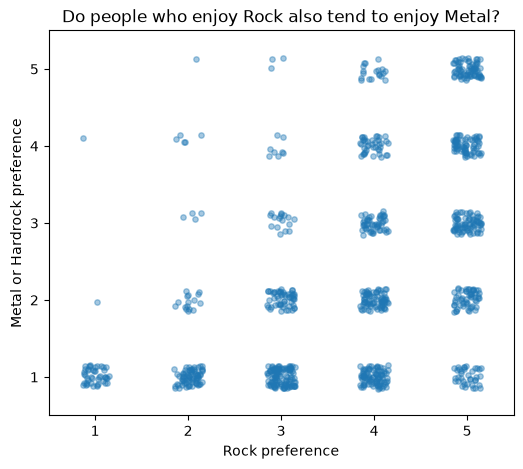

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Add jitter to make overlapping observations visible
rng = np.random.default_rng(42)

rock = music_data["Rock"]
metal = music_data["Metal or Hardrock"]

rock_jitter = rock + rng.uniform(-0.15, 0.15, len(rock))
metal_jitter = metal + rng.uniform(-0.15, 0.15, len(metal))

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(rock_jitter, metal_jitter, s=15, alpha=0.4)

ax.set(
    xlabel="Rock preference",
    ylabel="Metal or Hardrock preference",
    title="Do people who enjoy Rock also tend to enjoy Metal?",
    xlim=(0.5, 5.5),
    ylim=(0.5, 5.5),
)

ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))

plt.show()

**Can we identify broader patterns in people's music preferences?**

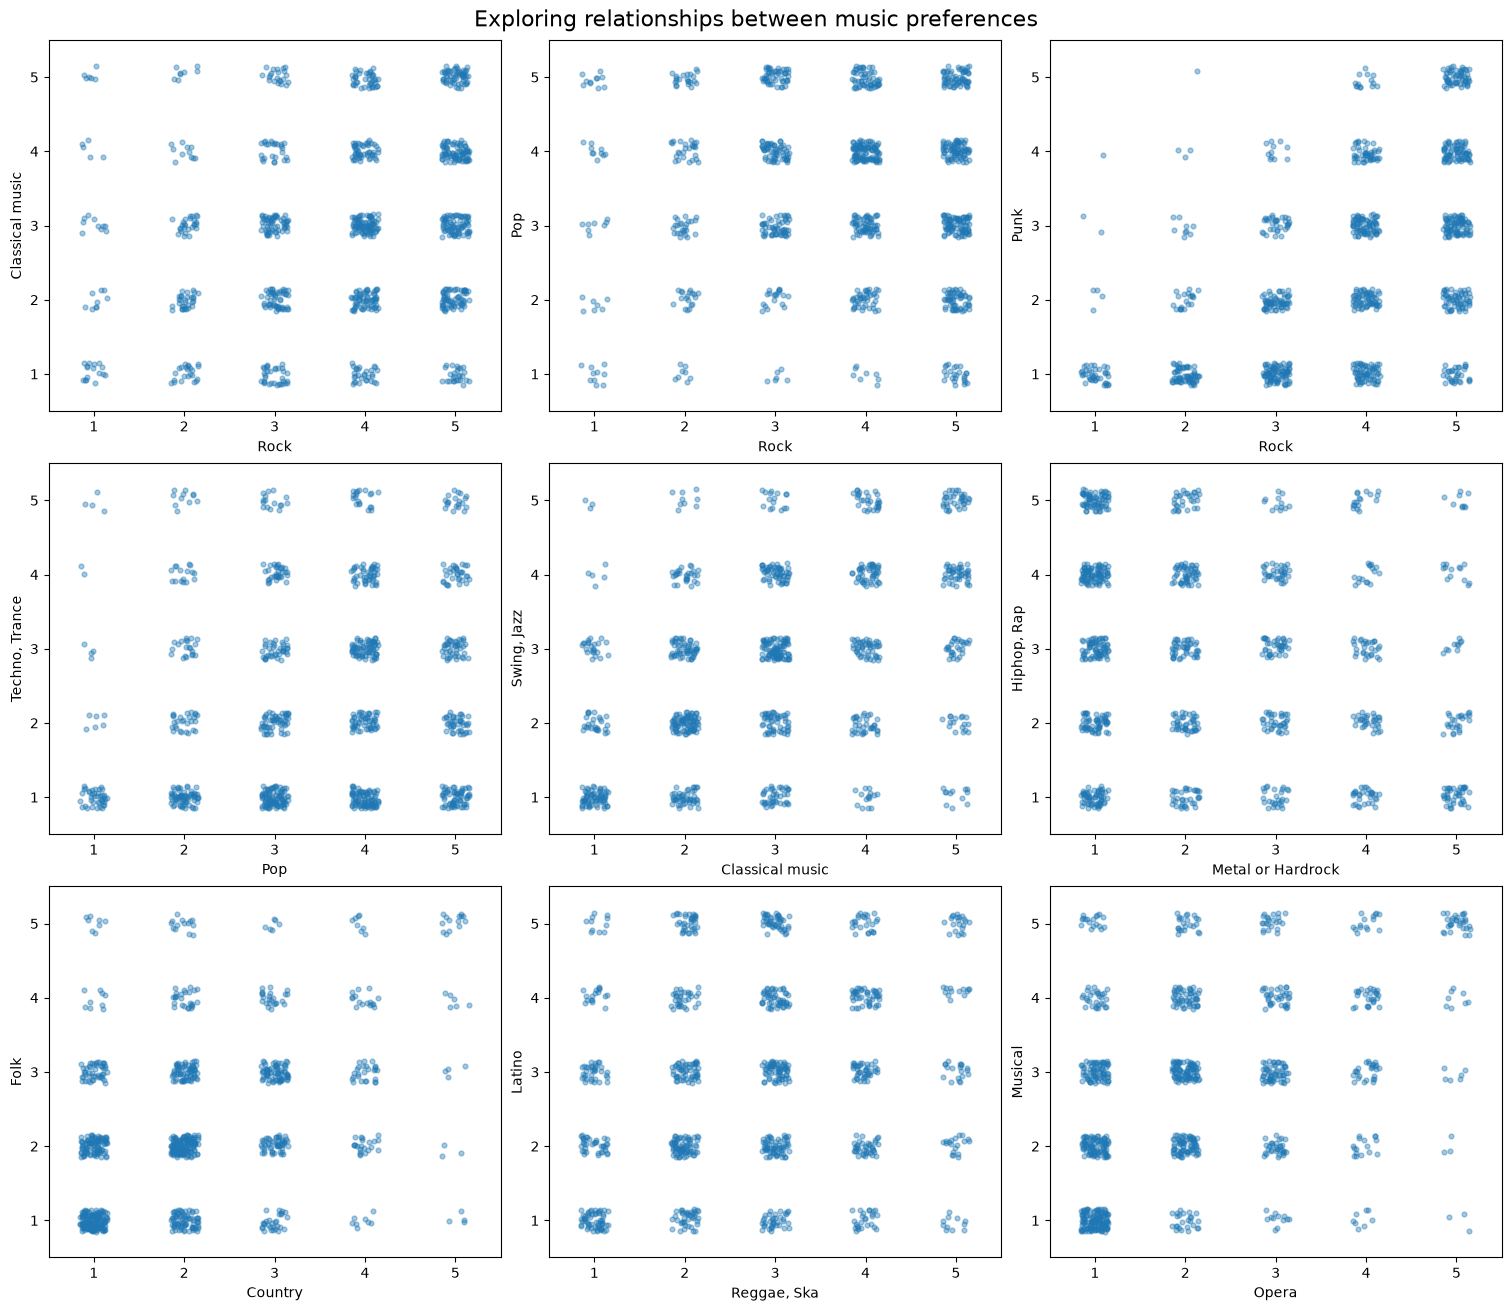

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Select nine pairs of music genres
pairs = [
    ("Rock", "Classical music"),
    ("Rock", "Pop"),
    ("Rock", "Punk"),
    ("Pop", "Techno, Trance"),
    ("Classical music", "Swing, Jazz"),
    ("Metal or Hardrock", "Hiphop, Rap"),
    ("Country", "Folk"),
    ("Reggae, Ska", "Latino"),
    ("Opera", "Musical"),
]

# Create a 3 x 3 grid
fig, axes = plt.subplots(
    3, 3, figsize=(15, 13), constrained_layout=True
)

rng = np.random.default_rng(42)

for ax, (genre_x, genre_y) in zip(axes.flat, pairs):

    # Add jitter to make overlapping ratings visible
    x = music_data[genre_x] + rng.uniform(-0.15, 0.15, len(music_data))
    y = music_data[genre_y] + rng.uniform(-0.15, 0.15, len(music_data))

    ax.scatter(x, y, s=12, alpha=0.4)

    ax.set_xlabel(genre_x)
    ax.set_ylabel(genre_y)
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(0.5, 5.5)
    ax.set_xticks(range(1, 6))
    ax.set_yticks(range(1, 6))

fig.suptitle(
    "Exploring relationships between music preferences",
    fontsize=16
)

plt.show()

### The challenge: Understanding the bigger picture

Scatter plots allow us to investigate relationships between two variables at a time. But our dataset contains 19 music preferences, and each participant has a unique combination of preferences.

We might expect some preferences to be correlated, revealing recurring patterns. For example, some people may enjoy both `Rock` and `Metal`, while others may prefer `Classical music` and `Jazz`.

However, music preferences can also overlap in more complex ways. Some participants may enjoy `Pop` and `Reggae` but not `Latino music`, while others may enjoy `Latino music` and `Reggae` but not `Pop`.

**How can we identify these broader patterns when considering all 19 music genres simultaneously?**

Dimensionality reduction offers a way to approach this problem by representing our 19 original features using just two or three new dimensions that capture as much of the original variation as possible.

**Here we can see how three different methods — PCA, t-SNE, and UMAP — represent the same dataset in two new dimensions.**

Dataset: 931 participants, 19 features


/Users/anasto/Documents/DSL_Teaching/CAS_ADS_M3_Oct_2026/machine-learning/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


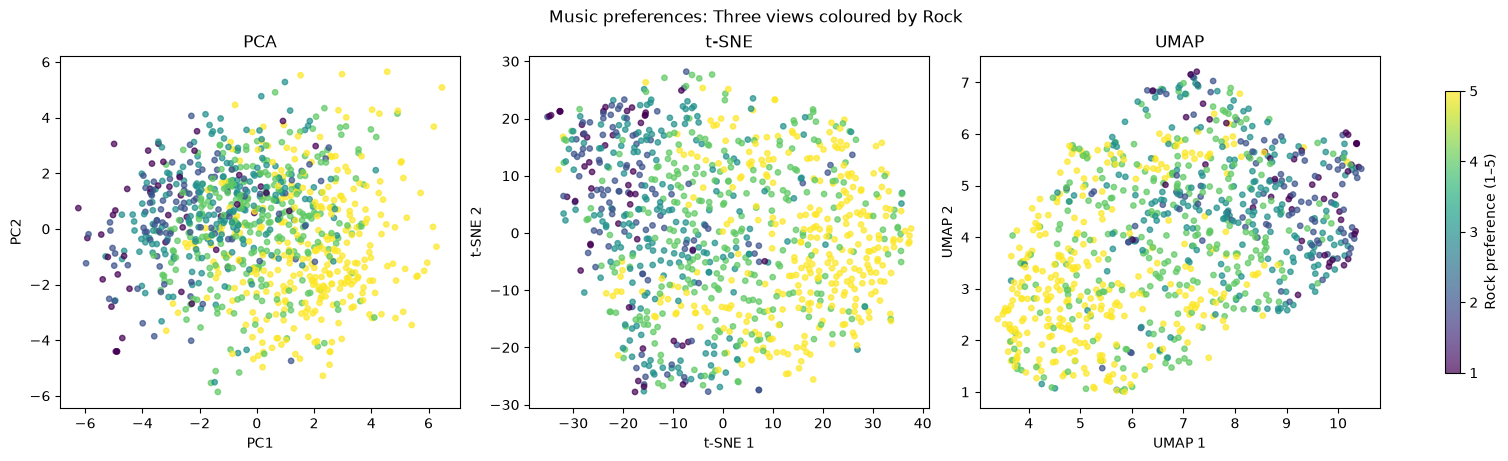

In [78]:
import matplotlib.pyplot as plt
import umap

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X = music_data.to_numpy(dtype=float)

print(f"Dataset: {X.shape[0]} participants, {X.shape[1]} features")

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
)
X_tsne = tsne.fit_transform(X)

# UMAP
reducer = umap.UMAP(
    n_components=2,
    random_state=42,
)
X_umap = reducer.fit_transform(X)

# Figure: Colour all three plots by Rock preference
rock = music_data["Rock"]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 4.5), constrained_layout=True
)

embeddings = [
    (X_pca, "PCA", "PC1", "PC2"),
    (X_tsne, "t-SNE", "t-SNE 1", "t-SNE 2"),
    (X_umap, "UMAP", "UMAP 1", "UMAP 2"),
]

for ax, (embedding, title, xlabel, ylabel) in zip(axes, embeddings):
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=rock,
        cmap="viridis",
        vmin=1,
        vmax=5,
        s=15,
        alpha=0.7,
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# One shared colour bar for all three plots
fig.colorbar(
    scatter,
    ax=axes,
    label="Rock preference (1–5)",
    ticks=[1, 2, 3, 4, 5],
    shrink=0.8,
)

plt.suptitle("Music preferences: Three views coloured by Rock")
plt.show()

## 3.1 PCA as Linear Dimensionality Reduction

PCA identifies directions that capture the greatest variance in the data. By retaining only the first few principal components, we can represent a high-dimensional dataset using fewer variables.

**Limitations**

- **Linear projection:** PCA identifies linear combinations of features and may not capture complex nonlinear structures.
- **Information loss:** Projecting data onto two or three components is always possible for a dataset with sufficient dimensions, but the resulting representation may not preserve enough of the original variation.
- **Sensitivity to scale:** Features with larger variance can dominate the analysis. Therefore, appropriate preprocessing, such as feature scaling, may be necessary.

---
### **How PCA works**

PCA provides a new set of $M$ uncorrelated features for every data point, with $M \le D$. We will see that  new features in PCA are a linear combination of the original features, with weights given by the principal vectors.

If $M \ll D$ we get an effective dimensionality reduction.


Each data point, indexed by $p=1..N$, starts from an original $D$-dimensional space:

$$
\mathbf{x}^p = (x^p_{1},\ldots,x^p_{D})
$$

where $D$ is the **number of features**.

We want to find a more economical representation with $M$ components, e.g. $M=2$ (two coordinates):

$$
\mathbf{s}^p = (s^p_{1},\ldots,s^p_{M})
$$

How are the new components related to the previous ones? We have a reconstruction property:

$$
\mathbf{x}^p \approx \mathbf{x}^p_M \equiv \mathbf{m} + \sum_{j=1}^M s^p_{j} \ \mathbf{v_{j}}  \rightarrow ( \text{Reconstruction formula} ), 
$$

where $\mathbf{m}$ represents the mean of each feature for the entire dataset. Note that:

- PCA optimizes $\mathbf{v_{j}},\ j=1..M$, called the **principal components** or **principal vectors**, so that the reconstruction property holds optimally for every fixed $M$, minimizing the loss of information.

We can calculate the scores from the original features and the principal vectors using a scalar product.

Before calculating the scores, PCA **centers the data** by subtracting the mean of each feature. The vector $\mathbf{m}$ contains these feature means.

$$ 
s^p_{j} = ( \mathbf{x}^p - \mathbf{m} ) \cdot \mathbf{v_{j}} \rightarrow ( \text{Score calculation} )
$$

This connects the principal vectors and the scores: **each score is a linear combination of the centered features, with weights given by the principal vector**.

![PCA: principal component directions](figures/PCA_illustration.png)

---

### **Scaling the Features (preprocessing)**

As we have seen, PCA centers the data by subtracting the mean of each feature. However, **centering does not change the scale of the features**.

If features have very different variances, those with larger variance may dominate the principal components. We may therefore choose to scale the features before applying PCA. One common approach is **standardization**, which divides each centered feature by its standard deviation.

Scaling is not always necessary: the choice depends on whether differences in variance between the original features are meaningful for the analysis.

---

### **More on the Principal Vectors: Explained Variance**

**Orthonormality:**

$$
\mathbf{v}_1 = (v_{1,1},\ldots,v_{1,D}), ..., \mathbf{v}_M = (v_{M,1},\ldots,v_{M,D})
$$

$$
\mathbf{v}_{i} \cdot \mathbf{v}_{j} = \delta_{i,j}
$$

The variance of the points in the dataset can be approximated by the variance of the reconstructed points. In particular, we have the decomposition of the total variance:

$$
S^2 = \frac{1}{N}\sum_{p=1}^{N}  |\mathbf{x}_p - \mathbf{m}|^2 = \epsilon_1 + \epsilon_2 + \ldots + \epsilon_D
$$

where:
- $\epsilon_1$: variance of the reconstructed points $\mathbf{x}^p_{M=1}$, also called the variance explained by the first principal component
- $\epsilon_1 + \epsilon_2$: variance of the reconstructed points $\mathbf{x}^p_{M=2}$, also called the variance explained by the first two components
- $\ldots$
- $S^2 = \epsilon_1 + \epsilon_2 + \ldots + \epsilon_D$

It turns out that **minimizing the reconstruction error is equivalent to maximize the variance of the reconstructed points**. The $\epsilon$ values are called the **explained variance**.

The ratios:

$$
\rho_1 = \frac{\epsilon_1}{S^2},\ \rho_2 = \frac{\epsilon_2}{S^2},\ldots
$$

are called the **explained variance ratio**, and their cumulative sums:

$$
r_1 = \frac{\epsilon_1}{S^2},\ r_2 = \frac{\epsilon_1 + \epsilon_2}{S^2},\ldots,\ r_D = 1
$$

are the **cumulative explained variance ratio**.

The plot of the explained variance ratio as a function of the number of components is called a *scree plot* and serves to select an optimal value of $M$ (if it exists). If $M$ is small, we have obtained a new, more compact data representation.

---

### **Terminology to Remember**

- **Principal components:** A sequence of orthonormal vectors $\mathbf{v}_1,\ldots,\mathbf{v}_n$. These vectors represent the typical patterns found in the data, ordered from most to least important.
- **Scores:** For every sample point $p$, the new features (scores) are called $s_{p,i}$. They can be computed from the original representation and the principal vectors with a scalar product: $\mathbf{x}_p \cdot \mathbf{v}_i$
- **Explained variance:** For every $M$, the ratio between the variance of the reconstructed vectors and the total variance. The number of components is chosen by selecting an optimal $M$. The plot of the explained variance as a function of $M$ is called a *scree plot*.



**Note:** The principal component scores are uncorrelated with one another by construction. This means that, in the dataset used to fit PCA, the scores on one principal component have zero covariance with the scores on another.

<h2 style="color: #ff0000;">
  Case Study: Interpreting Music Preferences with PCA
</h2>

**Before applying PCA, let's consider our dataset:**

1. What are the starting vectors in our survey dataset? How many vectors do we have? How many features?
2. Will PCA change the number of "data points"?
3. Should we scale the music ratings before applying PCA? Why or why not?

### Applying and Interpreting PCA

What do the new dimensions represent?

We will use the [scikit-learn's PCA implementation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to explore:

- **Explained variance:** How much of the original variation is retained?
- **Principal components:** How are the new axes constructed?
- **Component weights:** Which music genres contribute to each axis?

### 3.1.1 **Explained variance** to select optimal number of components

In [79]:
pca=PCA()
pca.fit(music_data)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

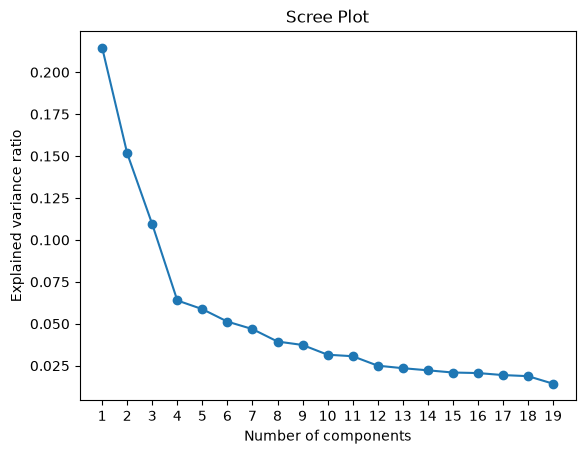

In [80]:
n_comps = np.arange(1,len(pca.explained_variance_ratio_)+1)
n_comps = [str(x) for x in n_comps]
plt.plot(n_comps,pca.explained_variance_ratio_,'-o')


plt.title('Scree Plot')
plt.xlabel('Number of components')
plt.ylabel('Explained variance ratio')

plt.show()

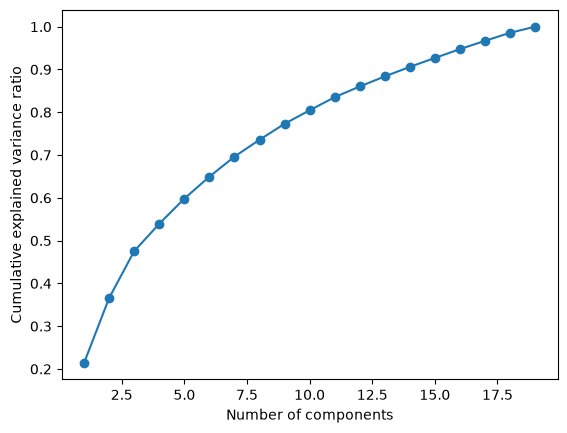

In [81]:
n_comps = np.arange(1, len(pca.explained_variance_ratio_) + 1)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(n_comps, cumulative_variance, "-o")

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance ratio")
plt.show()

**Interpreting the explained variance**

The curve shows an **elbow around four principal components**: beyond this point, each additional component contributes relatively little explained variance.

Retaining four components offers a possible compromise between reducing dimensionality and preserving the original variation.

However, the elbow is a heuristic, not a strict rule. The appropriate number of components depends on how much variance we want to retain and what we intend to do with the reduced data.

### 3.1.2 Computing **PCA Scores** and **Reconstructing** (filtering) music preferences

The following code computes the scores, the reconstructed vectors, and saves them in `df_scores` and `df_reconstructions`, that we are going to inspect. You do not have to understand all the code right now, you can come to this later...

In [82]:
scores = pca.transform(music_data)
print(scores.shape)

(931, 19)


In [83]:
def reconstruct_pca(pca, X, scores, k):
    """Reconstruct the original data using the first k principal components."""

    if k == 0:
        # With no components, every participant receives the average music profile
        recon = np.tile(pca.mean_, (X.shape[0], 1))

    else:
        # Reconstruct using the first k components
        recon = scores[:, :k] @ pca.components_[:k, :] + pca.mean_

    return pd.DataFrame(recon, columns=X.columns, index=X.index)


# Calculate and store the reconstructions
df_reconstructions = {}

for k in range(pca.n_components_ + 1):

    df_reconstructions[k] = reconstruct_pca(pca, music_data, scores, k)

    # Calculate reconstruction error
    mse_k = np.mean(
        (music_data.values - df_reconstructions[k].values) ** 2
    )

    print(f"k={k}: reconstruction MSE={mse_k:.6f}")

k=0: reconstruction MSE=1.447493
k=1: reconstruction MSE=1.136820
k=2: reconstruction MSE=0.917390
k=3: reconstruction MSE=0.759137
k=4: reconstruction MSE=0.666649
k=5: reconstruction MSE=0.581659
k=6: reconstruction MSE=0.507428
k=7: reconstruction MSE=0.439639
k=8: reconstruction MSE=0.382604
k=9: reconstruction MSE=0.328523
k=10: reconstruction MSE=0.282858
k=11: reconstruction MSE=0.238487
k=12: reconstruction MSE=0.202279
k=13: reconstruction MSE=0.168244
k=14: reconstruction MSE=0.136038
k=15: reconstruction MSE=0.105742
k=16: reconstruction MSE=0.075906
k=17: reconstruction MSE=0.047810
k=18: reconstruction MSE=0.020649
k=19: reconstruction MSE=0.000000



#### *Questions: Understanding PCA Reconstruction*
1. What are "scores"
2. What happens to the Mean Squared Error (MSE) as we retain more components? Why?
3. What happens when we do a reconstruction with retain no principal components ($M=0$)?
4. How does the reconstruction change when we retain four components ($M=4$)?

#### <span style="color: #007F86;">  *Solutions: Understanding PCA Reconstruction*

<span style="color: #007F86;">

**Scores:** The scores represent each observation's coordinates in the new coordinate system defined by the principal components.

**Reconstruction:** We calculate different reconstructions of the original data by retaining different numbers of principal components and evaluate their accuracy using the Mean Squared Error (MSE).

**MSE:** As we retain more components, the reconstruction error decreases because we recover more of the original variation.


<span style="color: #007F86;">Let's inspect the reconstructed vector with </span>$M=0$<span style="color: #007F86;">. In this case, the reconstructed vectors are simply the mean response, independent of the participant.</span>

$$ \mathbf{x}^p \approx \mathbf{x}_0^p =\mathbf{m} $$

In [84]:
#Reconstructions with M=0: a constant questionnaire, the mean response

df_reconstructions[0].head()

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,Punk,"Hiphop, Rap","Reggae, Ska","Swing, Jazz",Rock n roll,Alternative,Latino,"Techno, Trance",Opera
0,4.730397,3.316864,3.098818,2.281418,2.131042,2.962406,2.765843,3.468314,3.765843,2.360902,2.443609,2.893663,2.77014,2.765843,3.15145,2.84855,2.851772,2.320086,2.153598
1,4.730397,3.316864,3.098818,2.281418,2.131042,2.962406,2.765843,3.468314,3.765843,2.360902,2.443609,2.893663,2.77014,2.765843,3.15145,2.84855,2.851772,2.320086,2.153598
2,4.730397,3.316864,3.098818,2.281418,2.131042,2.962406,2.765843,3.468314,3.765843,2.360902,2.443609,2.893663,2.77014,2.765843,3.15145,2.84855,2.851772,2.320086,2.153598
3,4.730397,3.316864,3.098818,2.281418,2.131042,2.962406,2.765843,3.468314,3.765843,2.360902,2.443609,2.893663,2.77014,2.765843,3.15145,2.84855,2.851772,2.320086,2.153598
4,4.730397,3.316864,3.098818,2.281418,2.131042,2.962406,2.765843,3.468314,3.765843,2.360902,2.443609,2.893663,2.77014,2.765843,3.15145,2.84855,2.851772,2.320086,2.153598


<span style="color: #007F86;">Let's inspect the reconstructed vector with </span>$M=4$<span style="color: #007F86;">. Now we introduce variability. The reconstruction formula reads:</span>

$$
\mathbf{x}^p \approx \mathbf{x}^p_4
= \mathbf{m}
+ s^p_1 \mathbf{v}_1
+ s^p_2 \mathbf{v}_2
+ s^p_3 \mathbf{v}_3
+ s^p_4 \mathbf{v}_4
$$

<span style="color: #007F86;">where </span>$(s^p_1, s^p_2, s^p_3, s^p_4)$<span style="color: #007F86;"> are the new reduced variables describing participant </span>$p$<span style="color: #007F86;">, and the principal vectors are independent of the participant.</span>

In [85]:
#Reconstructions with M=4: a much better approximation, filtering the original questionnaire from noise

df_reconstructions[4].head()

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,Punk,"Hiphop, Rap","Reggae, Ska","Swing, Jazz",Rock n roll,Alternative,Latino,"Techno, Trance",Opera
0,4.443783,3.101317,1.871808,1.327182,1.362158,1.596480,1.976367,2.983629,3.017023,1.595517,1.716932,1.934483,1.625791,1.215209,1.993263,1.579758,1.761616,0.580842,1.117605
1,4.688636,3.392494,1.598379,1.164709,1.501258,1.571816,1.555508,2.484247,4.921724,3.830742,4.136255,2.140978,3.035803,2.036582,3.577167,3.333131,1.370339,0.614506,0.751708
2,4.858423,2.973534,2.308365,3.095606,2.937159,3.973396,4.127278,3.345256,5.289169,3.557318,3.762358,2.027791,3.730494,4.251779,4.992944,3.955198,3.781793,0.558233,3.001111
3,4.556951,3.498172,2.097179,1.027679,1.145681,1.626344,0.875378,2.369860,3.561065,2.842577,2.741582,2.260644,1.852594,1.145761,2.093516,2.608922,0.715617,2.113079,0.895970
4,4.721431,3.340263,4.139006,2.387206,2.161522,2.689043,3.291205,4.542136,2.802154,0.851907,1.210590,3.939264,2.830942,2.687580,2.609826,1.810727,3.918451,2.841581,2.057819


<span style="color: #007F86;">The PCA scores represent each participant's coordinates in the reduced space. By retaining only four scores instead of the original 19 features, we obtain a lower-dimensional representation of their music preferences.

In [86]:
df_scores = pd.DataFrame(
    scores,
    columns=[f"PC{i+1}" for i in range(scores.shape[1])],
    index=music_data.index
)

# Display only the first 4 components
display(df_scores.iloc[:, :4].head())

,PC1,PC2,PC3,PC4
0,-2.934651,-2.687434,-1.711381,-1.281837
1,0.532326,-4.278559,1.285371,-1.744518
2,4.523229,0.160923,-0.448430,-1.717596
3,-2.295308,-4.020336,0.437522,0.381947
4,-2.070914,2.607932,-0.272588,-0.229857


<span style="color: #007F86;">Finally, we can check that reconstrucing using a number of principal components equal to the number of the original features (19), we get back the original questionnaires:

In [87]:
#When using all 19 components we get back the original questionnaire

df_reconstructions[19].head()

,Music,Slow songs or fast songs,Dance,Folk,Country,Classical music,Musical,Pop,Rock,Metal or Hardrock,Punk,"Hiphop, Rap","Reggae, Ska","Swing, Jazz",Rock n roll,Alternative,Latino,"Techno, Trance",Opera
0,5.0,3.0,2.0,1.0,2.0,2.0,1.0,5.0,5.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0,1.0
1,4.0,4.0,2.0,1.0,1.0,1.0,2.0,3.0,5.0,4.0,4.0,1.0,3.0,1.0,4.0,4.0,2.0,1.0,1.0
2,5.0,5.0,2.0,2.0,3.0,4.0,5.0,3.0,5.0,3.0,4.0,1.0,4.0,3.0,5.0,5.0,5.0,1.0,3.0
3,5.0,3.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,4.0,2.0,2.0,1.0,2.0,5.0,1.0,2.0,1.0
4,5.0,3.0,4.0,3.0,2.0,4.0,3.0,5.0,3.0,1.0,2.0,5.0,3.0,2.0,1.0,2.0,4.0,2.0,2.0


### 3.1.3 Inspecting the **principal vectors**

The principal vectors describe patterns of variation in music preferences.

The reconstruction formula (reported here again):

$$
\mathbf{x}^p \approx \mathbf{x}^p_M
= \mathbf{m} + \sum_{j=1}^M s^p_j \mathbf{v}_j
$$

shows how each participant's music preferences are reconstructed using the principal vectors ($\mathbf{v}_j$), which describe the patterns of variation, and the corresponding scores ($s^p_j$), which determine how strongly each pattern contributes to that participant's reconstruction.

Now let's visualize the principal vectors fitted by `pca.fit()`.

In [88]:
df = pd.DataFrame(pca.components_.transpose(),
                  columns = [f'V_{i+1}' for i in range(len(music_columns))],
                  index=music_columns)
df

,V_1,V_2,V_3,V_4,V_5,V_6,V_7,V_8,V_9,V_10,V_11,V_12,V_13,V_14,V_15,V_16,V_17,V_18,V_19
Music,0.034327,0.030242,0.058575,0.003401,-0.005648,0.070442,-0.072589,-0.046377,0.002965,-0.044203,0.005060,0.112661,-0.011120,-0.114572,0.140985,0.138319,0.223307,-0.223824,0.902855
Slow songs or fast songs,-0.038844,-0.001008,0.150553,0.058194,-0.098439,0.037892,0.008159,0.023107,0.106553,0.048223,0.046499,0.469155,0.196216,-0.302002,0.408006,0.491768,-0.244483,-0.258269,-0.245515
Dance,-0.108185,0.351080,0.242687,0.144840,-0.215340,0.140691,0.072253,-0.150583,0.106101,-0.007872,-0.225787,0.284248,0.454947,0.441326,0.126784,-0.223653,0.171112,0.224983,0.016402
Folk,0.198776,0.190829,-0.165786,0.110605,-0.005172,-0.214301,0.350442,-0.290317,0.367466,-0.340010,-0.047813,0.350712,-0.189948,-0.291911,-0.329439,-0.068718,0.136498,0.024515,-0.040103
Country,0.170824,0.140712,-0.074469,0.013157,-0.127616,-0.205966,0.493252,-0.371091,-0.024814,0.188480,0.321041,-0.317403,-0.049683,0.341773,0.253690,0.175941,-0.060453,-0.217247,0.013842
Classical music,0.321165,0.154089,-0.246121,0.335864,0.050521,-0.112244,-0.242079,-0.058894,-0.227351,-0.237305,-0.084052,-0.144460,0.040855,-0.015306,0.203028,0.416664,0.063652,0.515503,0.006618
Musical,0.195235,0.315976,-0.227786,-0.189421,-0.212367,-0.041638,-0.419096,0.113744,0.242206,0.473885,0.297234,0.237463,-0.195298,0.144131,-0.132668,0.080119,0.153356,0.055279,-0.037238
Pop,-0.102153,0.323553,0.093759,-0.191536,-0.354285,0.196396,-0.257379,-0.313967,-0.084972,-0.267280,-0.222586,-0.120422,-0.331245,0.039526,-0.088276,0.056829,-0.484205,-0.097763,0.038331
Rock,0.307950,-0.116657,0.196066,-0.138037,-0.298001,0.155711,-0.095854,-0.090328,-0.178293,-0.158085,-0.070379,-0.057146,-0.217821,-0.127137,0.302390,-0.159884,0.586401,-0.189754,-0.279609
Metal or Hardrock,0.337369,-0.277790,0.224637,0.107211,-0.356716,-0.218770,0.118212,0.386633,-0.140126,-0.183835,0.168455,0.283392,-0.181362,0.251764,-0.013434,-0.139735,-0.303840,0.133485,0.142317


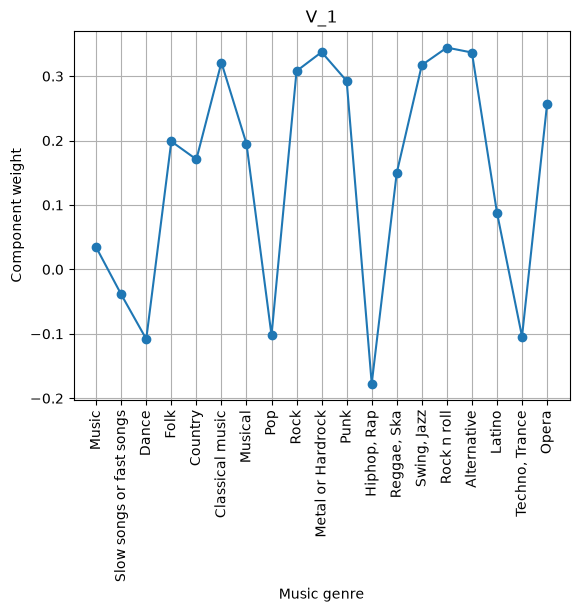

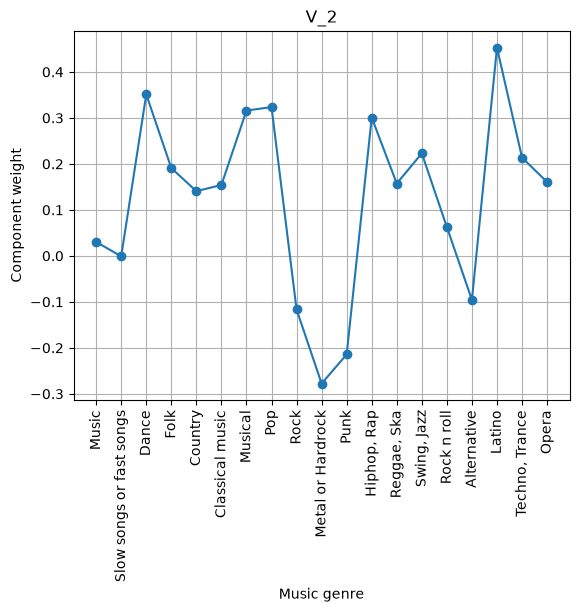

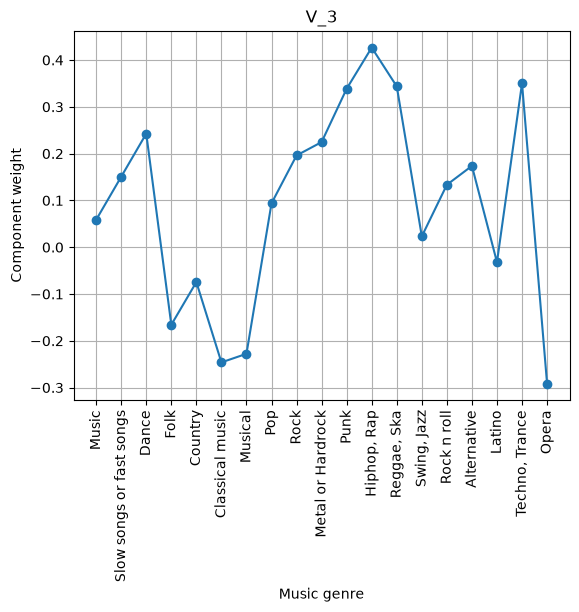

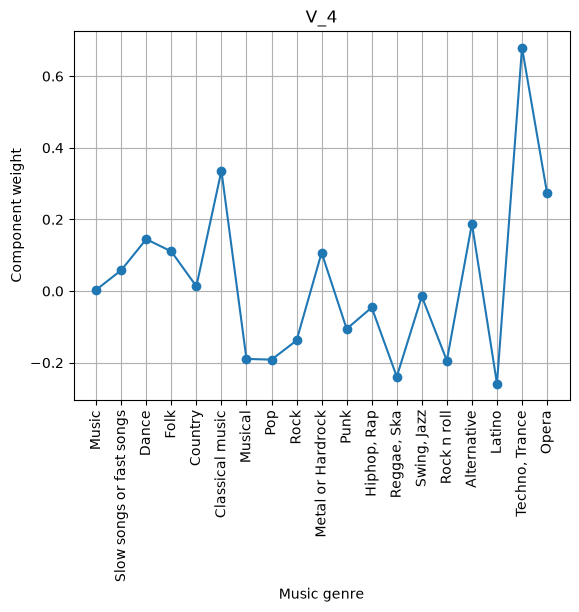

In [89]:
for vector in ['V_1', 'V_2', 'V_3', 'V_4']:
    plt.figure()
    plt.title(vector)
    plt.plot(np.arange(len(music_columns)), df[vector], '-o')
    plt.xticks(np.arange(len(music_columns)), music_columns, rotation=90)
    plt.xlabel("Music genre")
    plt.ylabel("Component weight")
    plt.grid()
    plt.show()

## 3.2 PCA for Denoising

In this example, we explore how PCA can be used to remove noise from images.

The example is adapted from the [scikit-learn’s PCA denoising example](https://scikit-learn.org/stable/auto_examples/applications/plot_digits_denoising.html) and uses the USPS handwritten digits dataset. Each image is 16 × 16 pixels.

In [90]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from skimage.util import random_noise



import matplotlib.pyplot as plt
def plot_digits(X, title):
    """Small helper function to plot 100 digits."""
    fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(8, 8))
    for img, ax in zip(X, axs.ravel()):
        ax.imshow(img.reshape((16, 16)), cmap="Greys")
        ax.axis("off")
    fig.suptitle(title, fontsize=24)
X, _ = fetch_openml(data_id=41082, as_frame=False, return_X_y=True)


In [91]:
# Add Gaussian noise to the images
X_noise = random_noise(X, mode='gaussian', var=0.1)

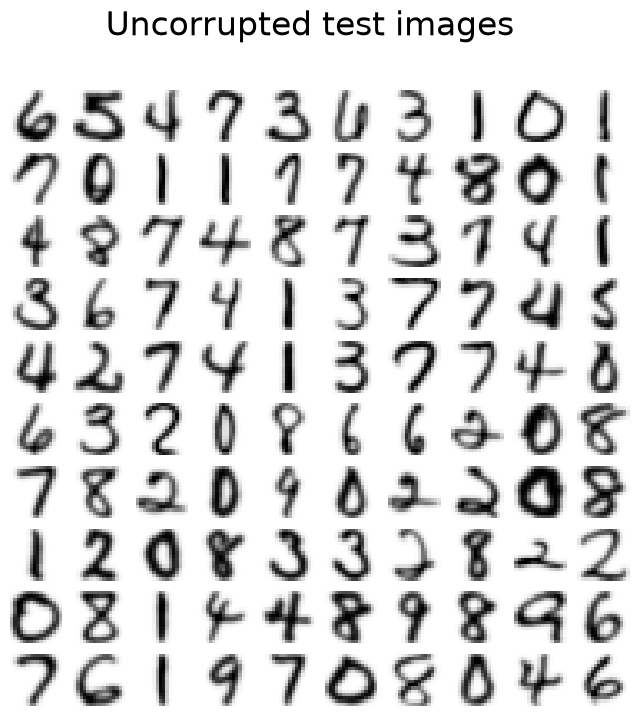

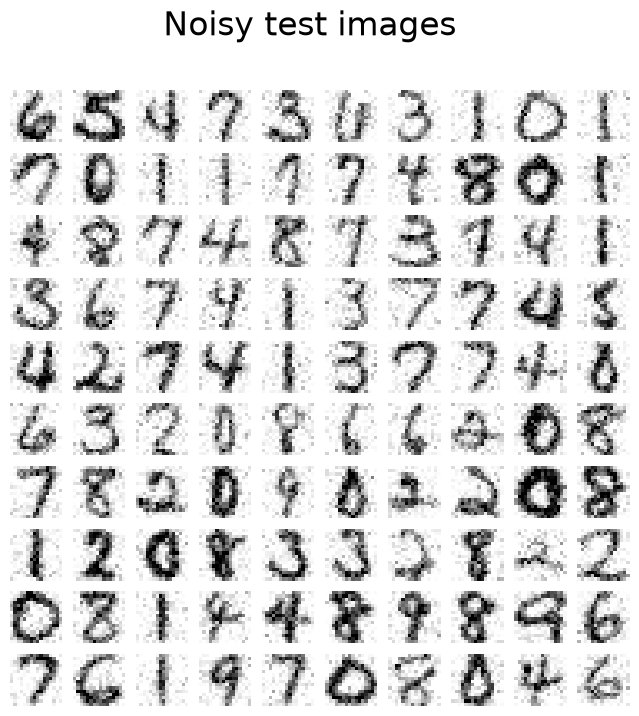

In [92]:
plot_digits(X, "Uncorrupted test images")
plot_digits(X_noise, f"Noisy test images")

Each image contains $16 \times 16 = 256$ pixel values (features). We fit PCA to the original images and retain only **32 principal components**.

The `transform()` step represents each image using 32 scores instead of 256 pixel values. The `inverse_transform()` step then uses these scores to reconstruct an approximation of the original image.

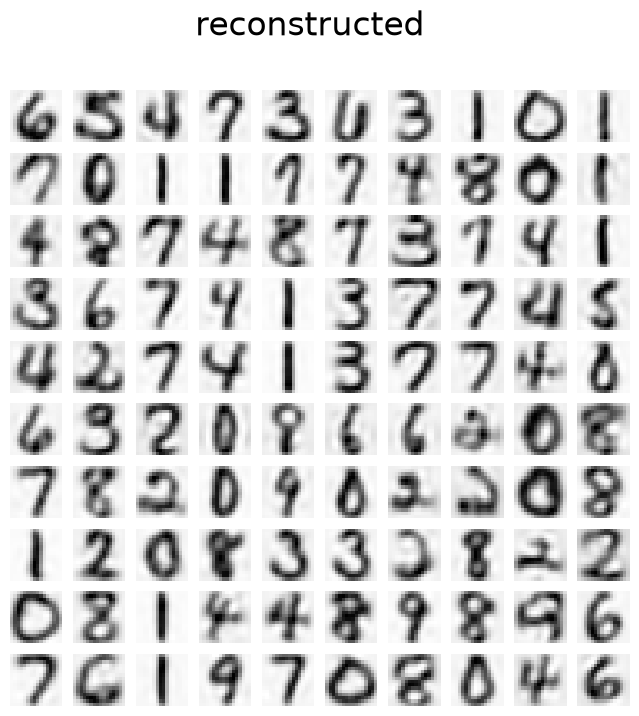

In [93]:
pca = PCA(n_components=32)
pca.fit(X)
X_reconstructed = pca.inverse_transform(pca.transform(X))
plot_digits(X_reconstructed,'reconstructed')

By keeping only the main directions of variation, we lose some detail while preserving much of the structure of the handwritten digits.

## 3.2 Nonlinear Dimensionality Reduction

We have seen how PCA represents each respondent using a smaller number of scores. By plotting the first two scores ($s_1$ and $s_2$), we can visualize the dataset in two dimensions. See this [book](https://www.fbbva.es/wp-content/uploads/2017/05/dat/DE_2010_biplots_in_practice.pdf) for a deeper introduction on visualization using PCA.

How informative this plot is depends on how much variation the first two components retain and whether the structure we are interested in is visible in those directions.

Next, we will compare this linear representation with **t-SNE** and **UMAP**, two nonlinear dimensionality-reduction methods.

---
### How do t-SNE and UMAP work?

Both methods start by identifying which observations are similar in the original high-dimensional space. They then arrange the observations in a lower-dimensional space, usually two dimensions, while trying to preserve these relationships.

- **t-SNE** uses probabilities to describe how similar pairs of observations are. It aims to keep observations with high similarity close together in the visualization.
- **UMAP** builds a graph connecting neighbouring observations. It then creates a lower-dimensional representation that aims to preserve the structure of these neighbourhoods.

Both methods focus strongly on **local structure**: which observations are close to one another. Distances between widely separated groups in the resulting plots should therefore be interpreted with caution.

We will focus on interpreting the visualizations rather than deriving the algorithms. For further details, see the original publications:

- [t-SNE (van der Maaten & Hinton, 2008)](https://lvdmaaten.github.io/publications/papers/JMLR_2008.pdf)
- [UMAP (McInnes et al., 2018)](https://arxiv.org/pdf/1802.03426.pdf)

We start by creating a t-SNE model and a UMAP model. Both will reduce high-dimensional data to two dimensions for visualization (*n_components=2*).

We set random_state to make the results reproducible.

In [94]:
import umap
from sklearn.manifold import TSNE

tsne_model = TSNE(perplexity=30, n_components=2, learning_rate=200, early_exaggeration=4.0,init='pca',
                      max_iter=2000, random_state=2233212, metric='euclidean', verbose=100 )

umap_model = umap.UMAP(n_neighbors=30, n_components=2, random_state=1711)


Both t-SNE and UMAP construct their embeddings through an iterative optimization process: they repeatedly adjust the positions of points to preserve neighbourhood relationships as well as possible.

The resulting low-dimensional embedding, and therefore its visualization (projection), depends on the chosen **hyperparameters**. For example, `perplexity` in t-SNE and `n_neighbors` in UMAP influence the neighbourhood scale considered by each method. t-SNE also exposes optimization settings such as `learning_rate` and `max_iter`.

UMAP is often faster than conventional t-SNE implementations, especially on larger datasets. However, neither method guarantees that distances between widely separated groups are preserved. We should therefore treat both embeddings as exploratory visualizations and check whether apparent patterns remain stable when we change the parameters.

### 3.2.1 The Heart dataset

In [95]:
from utils.routines import *

In this example, we generate a synthetic dataset using a function defined in utils/routines.py.

In [96]:
data= load_ex2_data_pca(seed=13423, n_add=20)
print(data.shape)

(651, 10)


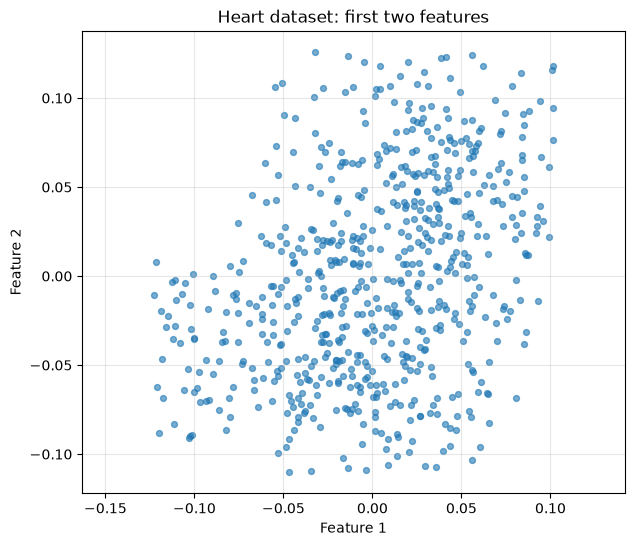

In [97]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(data[:, 0], data[:, 1], s=18, alpha=0.6)

ax.set(
    title="Heart dataset: first two features",
    xlabel="Feature 1",
    ylabel="Feature 2",
)
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)

plt.show()

**The effect of "perplexity" on the t-SNE embedding**

In [98]:
tsne_model = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3, verbose=1)

tsne_heart = tsne_model.fit_transform(data)

[t-SNE] Computing 10 nearest neighbors...
[t-SNE] Indexed 651 samples in 0.000s...
[t-SNE] Computed neighbors for 651 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 651 / 651
[t-SNE] Mean sigma: 0.025742
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.232262
[t-SNE] KL divergence after 1000 iterations: 0.885790


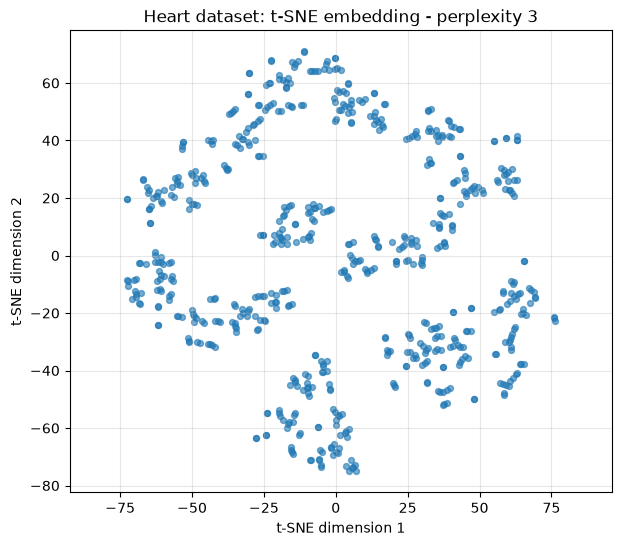

In [99]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(tsne_heart[:, 0], tsne_heart[:, 1], s=18, alpha=0.6)

ax.set(
    title="Heart dataset: t-SNE embedding - perplexity 3",
    xlabel="t-SNE dimension 1",
    ylabel="t-SNE dimension 2",
)
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)

plt.show()

In [100]:
tsne_model = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=10, verbose=1)

tsne_heart = tsne_model.fit_transform(data)

[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 651 samples in 0.000s...
[t-SNE] Computed neighbors for 651 samples in 0.005s...
[t-SNE] Computed conditional probabilities for sample 651 / 651
[t-SNE] Mean sigma: 0.042758
[t-SNE] KL divergence after 250 iterations with early exaggeration: 58.669468
[t-SNE] KL divergence after 1000 iterations: 0.805862


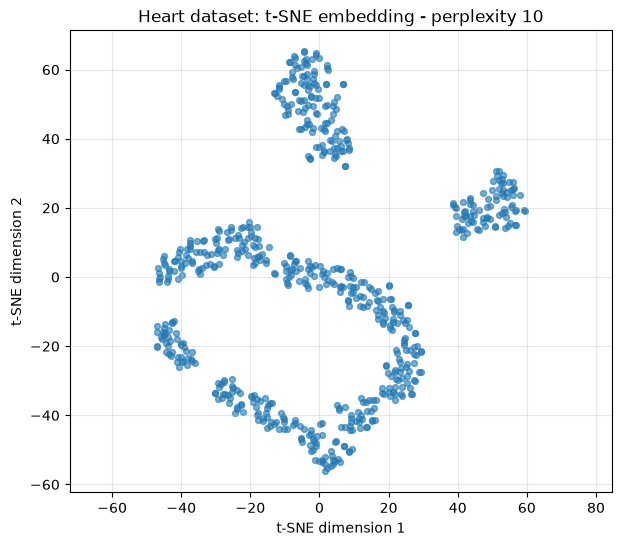

In [101]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(tsne_heart[:, 0], tsne_heart[:, 1], s=18, alpha=0.6)

ax.set(
    title="Heart dataset: t-SNE embedding - perplexity 10",
    xlabel="t-SNE dimension 1",
    ylabel="t-SNE dimension 2",
)
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)

plt.show()

Next, we generate a two-dimensional embedding of the same dataset using UMAP.

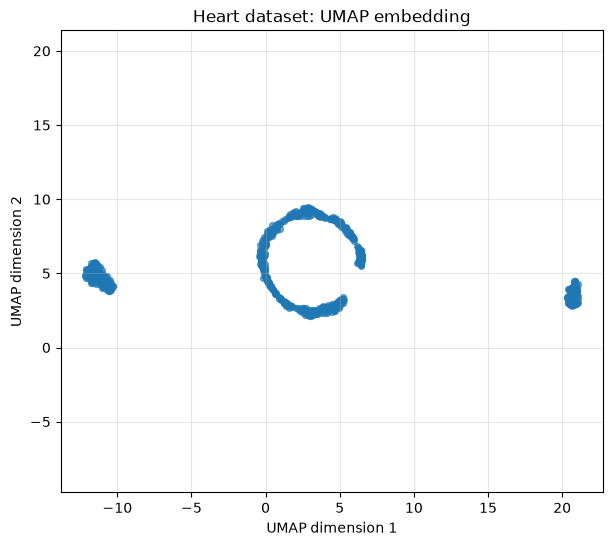

In [102]:
umap_model = umap.UMAP(n_neighbors=30, n_components=2, random_state=1711, n_jobs=1)

umap_heart = umap_model.fit_transform(data)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(umap_heart[:, 0], umap_heart[:, 1], s=18, alpha=0.6)

ax.set(
    title="Heart dataset: UMAP embedding",
    xlabel="UMAP dimension 1",
    ylabel="UMAP dimension 2",
)
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)

plt.show()

### 3.2.2 The MNIST dataset

The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. The digits have been size-normalized and centered in a fixed-size image.
It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting (taken from http://yann.lecun.com/exdb/mnist/). Each example is a 28x28 grayscale image and the dataset can be readily downloaded from Tensorflow.

In [103]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    return_X_y=True
)

X = X / 255.0  # Scale pixel values to [0, 1]

train_images = X.reshape(-1, 28, 28)
train_labels = y

print(train_images.shape)

(70000, 28, 28)


Let's check few samples:

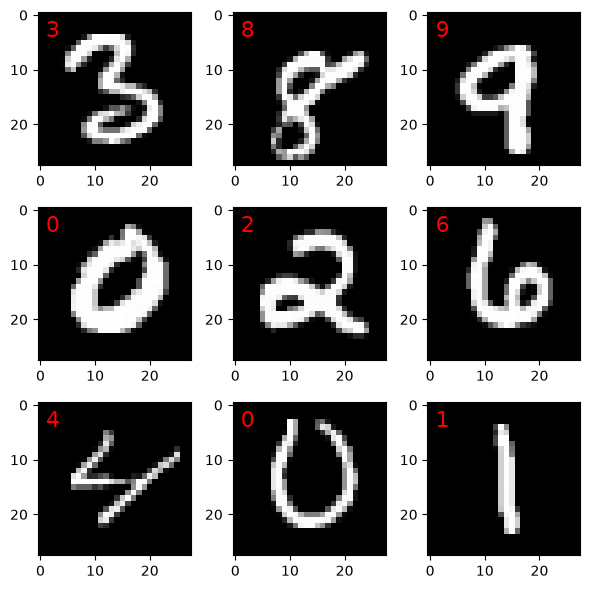

In [104]:
n = 3
fig, ax = plt.subplots(n, n, figsize=(2*n, 2*n))
ax = [ax_xy for ax_y in ax for ax_xy in ax_y]
for axi, im_idx in zip(ax, np.random.choice(len(train_images), n**2)):
  im = train_images[im_idx]
  im_class = train_labels[im_idx]
  axi.imshow(im, cmap='gray')
  axi.text(1, 4, f'{im_class}', color='r', size=16)
  axi.grid(False)
plt.tight_layout()
plt.show()

Let's take a subset of the MNIST dataset

In [105]:
n_examples = 5000

data = X[:n_examples]
labels = y[:n_examples]

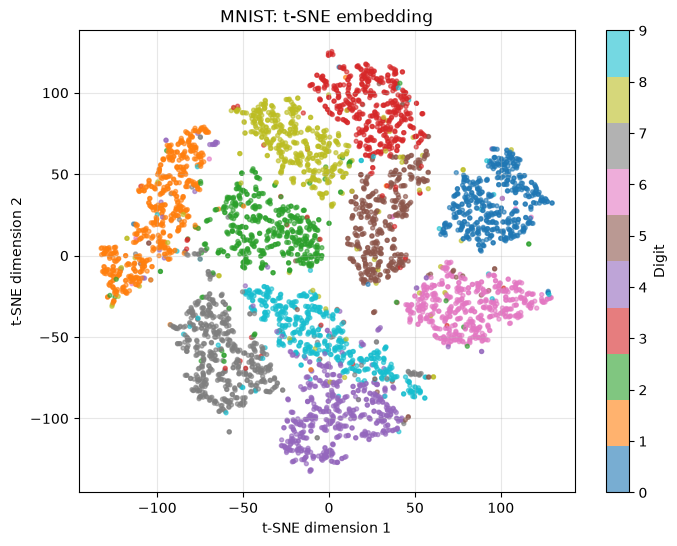

In [ ]:
# Optional: t-SNE visualization of MNIST
# This calculation can take several minutes, so it is disabled by default.
# To run it, select the code below and toggle comments (Cmd+/ or Ctrl+/).

# tsne_model = TSNE(
#     perplexity=10,
#     n_components=2,
#     learning_rate=200,
#     early_exaggeration=4.0,
#     init="pca",
#     max_iter=2000,
#     random_state=2233212,
#     metric="euclidean",
#     n_jobs=1,
# )

# tsne_mnist = tsne_model.fit_transform(data)

# fig, ax = plt.subplots(figsize=(8, 6))
# scatter = ax.scatter(
#     tsne_mnist[:, 0],
#     tsne_mnist[:, 1],
#     c=labels.astype(int),
#     cmap="tab10",
#     s=8,
#     alpha=0.6,
# )
# ax.set(
#     title="MNIST: t-SNE embedding",
#     xlabel="t-SNE dimension 1",
#     ylabel="t-SNE dimension 2",
# )
# ax.grid(alpha=0.3)
# colorbar = fig.colorbar(scatter, ax=ax, ticks=range(10))
# colorbar.set_label("Digit")
# plt.show()

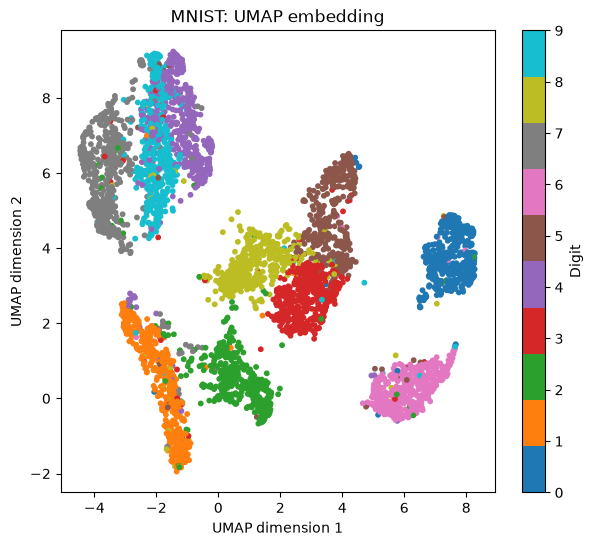

In [107]:
labels = y[:n_examples].astype(int)

umap_mnist = umap_model.fit_transform(data)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    umap_mnist[:, 0], umap_mnist[:, 1],
    c=labels, s=10, cmap="tab10"
)

ax.set(
    title="MNIST: UMAP embedding",
    xlabel="UMAP dimension 1",
    ylabel="UMAP dimension 2",
)
fig.colorbar(scatter, ax=ax, label="Digit")
plt.show()

### Exercise: Dimensionality Reduction with Fashion-MNIST

[**Fashion-MNIST**](https://github.com/zalandoresearch/fashion-mnist) contains 70,000 grayscale images of clothing items, divided into 10 classes. Each image is 28 × 28 pixels.

Apply the same dimensionality-reduction workflow we used for handwritten digits:

1. Load Fashion-MNIST from OpenML using `fetch_openml(data_id=40996, ...)`.
2. Select 5,000 images and prepare the pixel values and labels.
3. Generate a two-dimensional embedding using UMAP. Optionally, try t-SNE.
4. Colour the points by clothing category. Which categories appear well separated, and which overlap?

**Discussion:** Does an apparent group in the embedding necessarily mean that all images in that group belong to the same clothing category?

## 3.3 Bringing It All Together: Exploring the Ames Housing Dataset

We can combine the machine learning techniques introduced in this course to gain deeper insights into a dataset. In this final exercise, we use **UMAP** to visualize the houses, **HDBSCAN** to identify clusters, and a **random forest** to explore which housing characteristics distinguish the clusters.

Subset of the Ames Houses dataset: http://jse.amstat.org/v19n3/decock.pdf
The dataset was generated during the previous lecture and the code is stored in this notebook: 2-ML-SL-Linear.ipynb

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("data/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [109]:
# Select the two columns needed for this plot
plot_df = df[["Lot Area", "SalePrice"]].dropna()

# Apply the same limits as the original helper
plot_df = plot_df[
    (plot_df["SalePrice"] < 400000) &
    (plot_df["Lot Area"] < 40000)
]

x = plot_df[["Lot Area"]].to_numpy(dtype=np.float32)
y = plot_df["SalePrice"].to_numpy(dtype=np.float32)

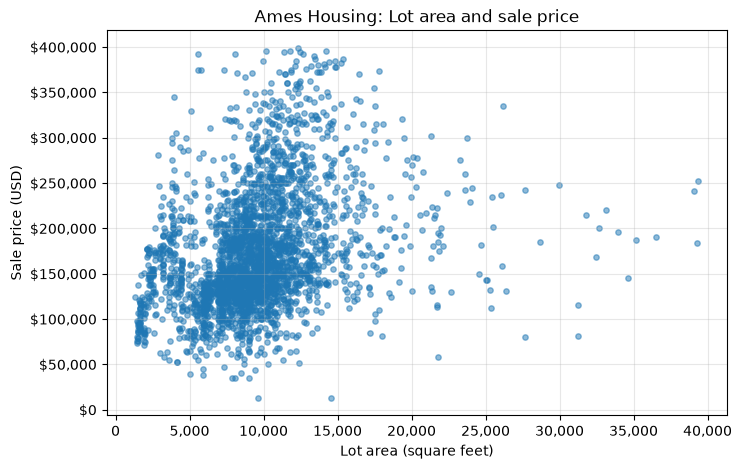

In [110]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(x[:, 0], y, s=15, alpha=0.5)

ax.set(
    title="Ames Housing: Lot area and sale price",
    xlabel="Lot area (square feet)",
    ylabel="Sale price (USD)",
)

ax.xaxis.set_major_formatter("{x:,.0f}")
ax.yaxis.set_major_formatter("${x:,.0f}")
ax.grid(alpha=0.3)

plt.show()

### 3.3.1 Dimensionality Reduction using UMAP

**In the case of the AMES dataset we must normalize somehow the dataset. Why?**

UMAP identifies neighbouring houses based on distances between their features. Since housing features have very different units and ranges, features with larger numerical scales could dominate these distances. We therefore standardize the features so that they contribute on a more comparable scale.

In [111]:
from sklearn.preprocessing import StandardScaler

houses = df.rename(columns=lambda c: c.replace(" ", "").replace("/", ""))

features = [
    "LotArea", "Utilities", "OverallQual", "OverallCond",
    "YearBuilt", "YearRemodAdd", "ExterQual", "ExterCond",
    "HeatingQC", "CentralAir", "Electrical",
    "1stFlrSF", "2ndFlrSF", "GrLivArea",
    "FullBath", "HalfBath", "BedroomAbvGr", "KitchenAbvGr",
    "KitchenQual", "TotRmsAbvGrd", "Functional", "PoolArea",
    "YrSold", "MoSold",
]

# Keep rows with complete data for the selected features and sale price
houses = houses.dropna(subset=features + ["SalePrice"])

# Convert categorical columns into numerical features
X = pd.get_dummies(houses[features], dtype=float)

x = X.to_numpy(dtype=np.float32)
y = houses["SalePrice"].to_numpy(dtype=np.float32)
data = StandardScaler().fit_transform(x)

In [112]:
umap_model = umap.UMAP(n_neighbors=30, n_components=2, random_state=1711, n_jobs=1)
umap_houses = umap_model.fit_transform(data)

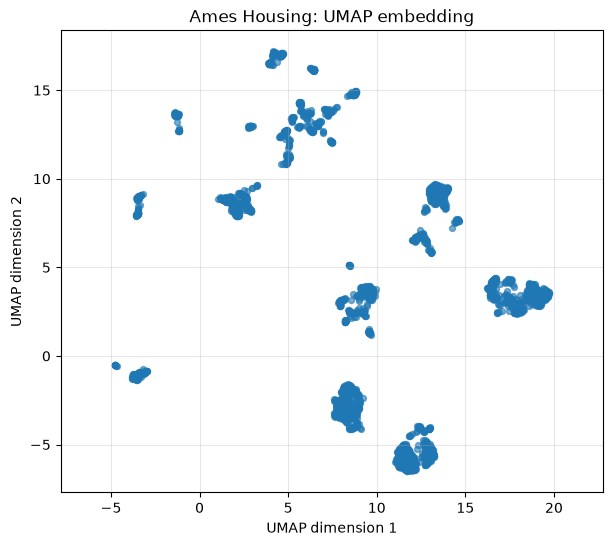

In [113]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(umap_houses[:, 0], umap_houses[:, 1], s=18, alpha=0.6)

ax.set(
    title="Ames Housing: UMAP embedding",
    xlabel="UMAP dimension 1",
    ylabel="UMAP dimension 2",
)
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)

plt.show()

In such a situation we do not have 'labels' to superimpose. To understand what are the features characterizing each clusters it time consuming and there is no general-purpose method.

The following techniques can be used:

1. **Visualization of Individual points:** Make an interactive App (e.g. using dash) that permits to visualize points quickly (e.g. if the dataset is made of images or texts)

2. **Colour plots:** Color the points according to a selected variable and check if points get mixed.

Using clustering techniques (you will here more about them next session), one can attach a cluster label to each point. After this step, an other range of exploration methodologies can be performed:

3. **Visualization of Centroids:** Make the mean of the each features across all members of one cluster. Compare between clusters. 

4. **Analyze distributions:** Make a descriptive analysis of the populations in the different clusters.

5. **Use cluster indexes as labels and apply supervised machine learning methods.** 

### 3.3.2 Identifying clusters with HDBSCAN

We now apply **HDBSCAN** to the two-dimensional UMAP embedding to identify groups of similar houses. The plot colors each house by its assigned cluster; points labeled `-1` are considered noise and are not assigned to a cluster.

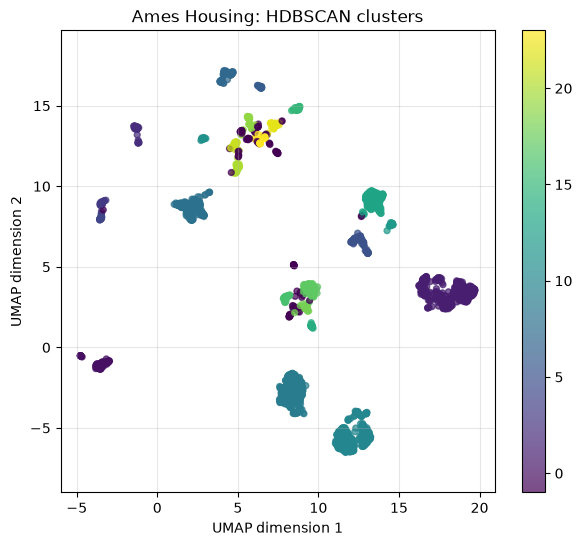

In [114]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=30, gen_min_span_tree=True)
clusterer.fit(umap_houses)

labels = clusterer.labels_
classes = set(labels) - {-1}  # -1 indicates noise (unassigned houses)

fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(
    umap_houses[:, 0],
    umap_houses[:, 1],
    c=labels,
    cmap="viridis",
    s=18,
    alpha=0.7,
)

ax.set(
    title="Ames Housing: HDBSCAN clusters",
    xlabel="UMAP dimension 1",
    ylabel="UMAP dimension 2",
)
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)

colorbar = fig.colorbar(scatter, ax=ax)

plt.show()

To understand what distinguishes the clusters, we add the HDBSCAN labels to the standardized housing features. We exclude houses that were not assigned to a cluster (`-1`) and prepare the resulting table for the next step: using a random forest to identify distinguishing features.

In [115]:
# Recreate the DataFrame with the correct feature names
cluster_df = pd.DataFrame(data, columns=X.columns, index=X.index)
cluster_df["cluster"] = clusterer.labels_

# Keep only houses assigned to a cluster and sort by cluster
df_2 = (
    cluster_df[cluster_df["cluster"] != -1]
    .sort_values(by="cluster")
)

df_2.head()

,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,1stFlrSF,2ndFlrSF,GrLivArea,FullBath,HalfBath,...,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sal,Functional_Sev,Functional_Typ,cluster
1559,-0.578814,1.350040,-0.506827,1.212210,1.138337,1.256457,-0.782876,0.301230,0.784244,-0.754849,...,-1.02035,-0.080804,-0.055517,-0.15065,-0.156474,-0.109973,-0.02614,-0.02614,0.272165,0
458,-0.350007,2.058817,-0.506827,1.212210,1.186284,1.848566,-0.782876,0.760177,0.784244,-0.754849,...,-1.02035,-0.080804,-0.055517,-0.15065,-0.156474,-0.109973,-0.02614,-0.02614,0.272165,0
459,-0.466505,2.058817,-0.506827,1.212210,1.138337,0.756226,-0.782876,-0.086501,0.784244,-0.754849,...,-1.02035,-0.080804,-0.055517,-0.15065,-0.156474,-0.109973,-0.02614,-0.02614,0.272165,0
2390,-0.026150,2.058817,-0.506827,1.112999,1.042441,1.187547,0.304997,1.169669,0.784244,1.235207,...,-1.02035,-0.080804,-0.055517,-0.15065,-0.156474,-0.109973,-0.02614,-0.02614,0.272165,0
2275,0.315347,2.767594,-0.506827,1.146069,1.090389,1.695435,-0.782876,0.641484,0.784244,-0.754849,...,-1.02035,-0.080804,-0.055517,-0.15065,-0.156474,-0.109973,-0.02614,-0.02614,0.272165,0


### 3.3.3 Interpreting the clusters with a random forest

We have identified groups of houses using HDBSCAN, but **what distinguishes each cluster from the others?** We can use a supervised learning method to explore this question.

For **each cluster**, we train a random forest to distinguish its houses from those in all other clusters. We then examine the **10 most important features** for the first two clusters as examples. You can change the plotting code to explore the remaining clusters.

Feature importances help us interpret the cluster assignments, but they do not prove that the clusters represent meaningful housing categories.

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

features = df_2.drop(columns="cluster")
cluster_labels = df_2["cluster"]

# Store results for every cluster
feature_importances = {}
results = []

for cluster in sorted(cluster_labels.unique()):
    # One cluster versus all other clusters
    y_binary = (cluster_labels == cluster).astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        features, y_binary,
        test_size=0.2,
        random_state=42,
        stratify=y_binary,
    )

    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
    )
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    results.append({
        "Cluster": cluster,
        "Houses": y_binary.sum(),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred),
    })

    feature_importances[cluster] = pd.Series(
        rf_model.feature_importances_,
        index=features.columns,
    )

# One compact summary instead of printing results for every model
pd.DataFrame(results)

,Cluster,Houses,Balanced accuracy
0,0,111,0.954545
1,1,488,0.967219
2,2,69,0.928571
3,3,44,0.722222
4,4,40,0.625000
5,5,98,0.500000
6,6,41,0.500000
7,7,108,0.953614
8,8,241,0.996086
9,9,341,0.975905


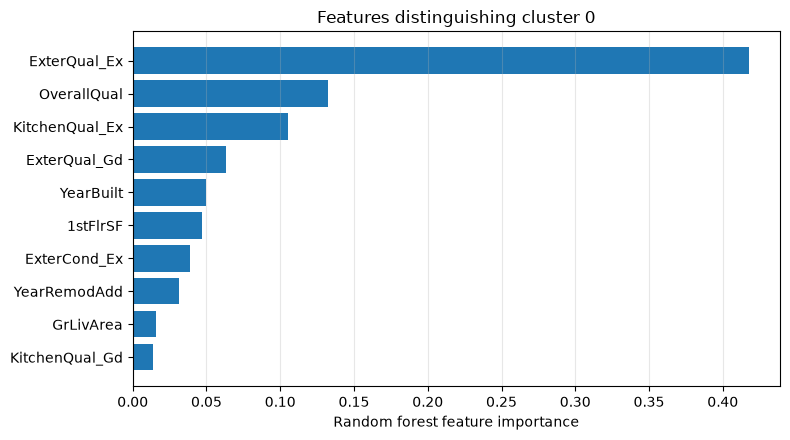

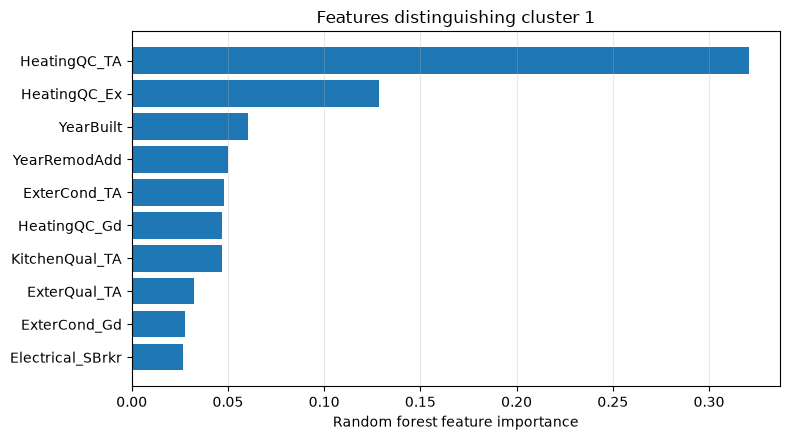

In [117]:
for cluster in sorted(feature_importances)[:2]:
    top_features = feature_importances[cluster].nlargest(10).sort_values()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(top_features.index, top_features.values)
    ax.set(
        title=f"Features distinguishing cluster {cluster}",
        xlabel="Random forest feature importance",
        ylabel="",
    )
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

**Further exploration:** We could also use SHAP (SHapley Additive exPlanations) to interpret the random forests. While the feature-importance plots show which features the models rely on most, SHAP can help us explore how individual features influence predictions for particular houses.

Like feature importance, SHAP explains the model's predictions—not whether the clusters themselves are meaningful.

## Final takeaways

Unsupervised learning helps us discover patterns in data without knowing in advance which groups or relationships to expect. **PCA** summarizes variation in fewer dimensions, while **t-SNE and UMAP** help us visualize relationships in complex datasets.

PCA transforms the original features into new coordinates, called **principal component scores**:

$$
(x_1, \ldots, x_D) \longrightarrow (s_1, \ldots, s_M)
$$

These scores are **uncorrelated in the dataset used to fit PCA**: they capture different directions of variation without a linear correlation between them. This does not mean they are completely independent or automatically easy to interpret—we still need to examine the component weights.

In the Ames Housing example, we combined **UMAP, HDBSCAN, and a random forest** to visualize houses, identify clusters, and explore which features distinguish those clusters.

**The key lesson:** The patterns we discover depend on preprocessing, feature scaling, methods, and parameter choices. PCA is sensitive to feature variances, and UMAP uses distances between observations. A clear visualization or cluster is therefore a starting point for investigation, not proof that we have found a meaningful group.

### Final takeaway: PCA scores and feature scaling

PCA transforms the original features into new coordinates, called **principal component scores**:

\[
(x_1, \ldots, x_D) \longrightarrow (s_1, \ldots, s_M)
\]

The scores are **uncorrelated** in the dataset used to fit PCA: knowing a house’s score on one component does not tell us whether its score on another component tends to be higher or lower. This does **not** mean the scores are completely independent. To interpret a component, we still need to examine its feature weights.

**Remember:** Preprocessing matters. PCA is influenced by the variance of the input features, while UMAP uses distances to identify neighbours. Scaling can therefore change the patterns we see in both methods.

## Appendix: Code to generate the PCA illustration plot

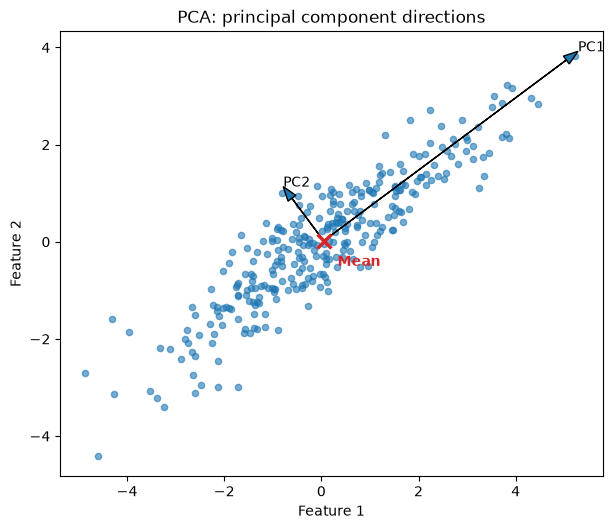

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reproducibility
rng = np.random.default_rng(42)

# Generate a simple 2D correlated dataset
mean = [0, 0]
cov = [[3.0, 2.2],
       [2.2, 2.0]]

X = rng.multivariate_normal(mean, cov, size=300)

# Fit PCA
pca = PCA(n_components=2)
pca.fit(X)

# Center of the data
center = X.mean(axis=0)

# Principal directions
pc1 = pca.components_[0]
pc2 = pca.components_[1]

# Scale arrows by explained variance for visualization
scale1 = 3 * np.sqrt(pca.explained_variance_[0])
scale2 = 3 * np.sqrt(pca.explained_variance_[1])

# Plot
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(X[:, 0], X[:, 1], s=20, alpha=0.6)

# Plot and label the mean
ax.scatter(center[0], center[1], marker="x", s=100,
           color="tab:red", linewidths=2.5, zorder=5)

ax.annotate(
    "Mean",
    xy=center,
    xytext=(10, -18),
    textcoords="offset points",
    color="tab:red",
    fontweight="bold"
)

# Plot PC1 arrow
ax.arrow(
    center[0], center[1],
    pc1[0] * scale1, pc1[1] * scale1,
    head_width=0.2, length_includes_head=True
)

# Plot PC2 arrow
ax.arrow(
    center[0], center[1],
    pc2[0] * scale2, pc2[1] * scale2,
    head_width=0.2, length_includes_head=True
)

# Labels
ax.text(center[0] + pc1[0] * scale1, center[1] + pc1[1] * scale1, "PC1")
ax.text(center[0] + pc2[0] * scale2, center[1] + pc2[1] * scale2, "PC2")

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("PCA: principal component directions")
ax.set_aspect("equal")
plt.show()